In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import roc_auc_score

In [ ]:
def flatten_columns(df):
    df.columns = [
        "_".join(col).upper() if isinstance(col, tuple) else col
        for col in df.columns
    ]
    return df

# Чтение данных

In [ ]:
DATA_PATH = 'data/processed'  # обработанные данные

In [ ]:
np.random.seed(91)

In [ ]:
df = pd.read_csv(DATA_PATH + "/uplift-dataset.csv")

print("Dataset shape:", df.shape)

Dataset shape: (307511, 161)


# Анализ синтетически сгенерированных данных

In [ ]:
df

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,SK_DPD_MAX_y,BASE_PD,CONTACT_PROPENSITY,RISK_SEGMENT,CONTACT_HISTORY,PREFERRED_CHANNEL,INTERACTION_SCORE,DELAY_FLAG,COMMUNICATION,TRUE_UPLIFT
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,NaN,0.942266,0.604584,high_risk,2,sms,0.450668,1,control,-0.004172
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,NaN,0.675329,0.496744,high_risk,6,sms,0.341462,1,operator_call,0.021453
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,NaN,0.184703,0.122720,low_risk,1,robot_call,0.483622,0,control,0.005577
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.361659,0.255447,low_risk,2,sms,0.461974,1,control,-0.009162
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,NaN,0.588942,0.395647,high_risk,2,sms,0.437186,1,control,0.007411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,NaN,0.604952,0.396909,high_risk,1,sms,0.469229,0,control,0.004865
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,NaN,0.690921,0.437166,high_risk,6,robot_call,0.467030,0,control,0.028971
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,NaN,0.470963,0.339280,medium_risk,1,sms,0.416992,0,robot_call,-0.047840
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,NaN,0.301405,0.214781,low_risk,0,operator_call,0.455039,1,control,0.002801


## 1. Проверка корректности генерации BASE_PD

Рассматривем распределение базовой вероятности дефолта (без коммуникаций). Ожидаем, что распределение носит непрерывный характер и охватывает весь диапазон значений.

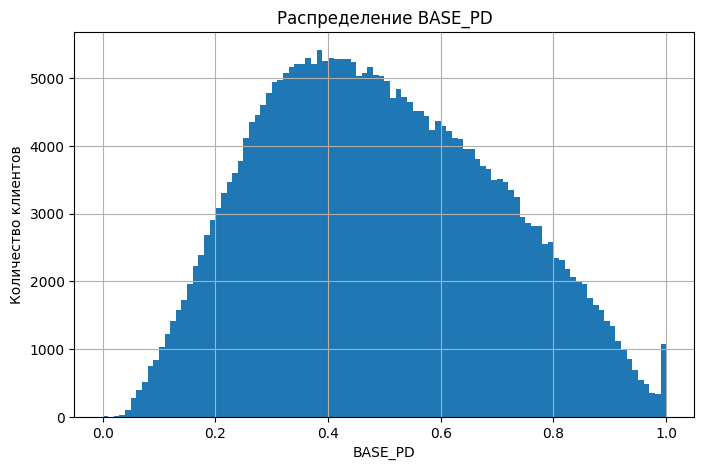

In [ ]:
plt.figure(figsize=(8, 5))
df['BASE_PD'].hist(bins=100)
plt.title("Распределение BASE_PD")
plt.xlabel("BASE_PD")
plt.ylabel("Количество клиентов")
plt.show()

Так же хотим убедиться, что сгенерированный BASE_PD отражает наш исходный таргет(вероятность дефолта), то есть что поле носит не случайный характер, а действителньо наблюдаем монотонный рост риска дефолта с увеличением BASE_PD.

/tmp/ipykernel_3202/728099310.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pd_by_bin = df.groupby("BASE_PD_BIN")["TARGET"].mean()


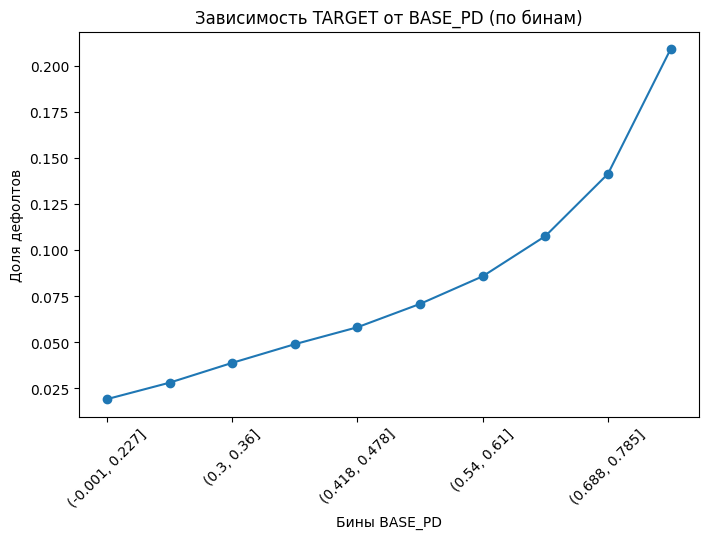

In [ ]:
df["BASE_PD_BIN"] = pd.qcut(df["BASE_PD"], q=10, duplicates="drop")

pd_by_bin = df.groupby("BASE_PD_BIN")["TARGET"].mean()

pd_by_bin.plot(marker="o", figsize=(8, 5))
plt.title("Зависимость TARGET от BASE_PD (по бинам)")
plt.xlabel("Бины BASE_PD")
plt.ylabel("Доля дефолтов")
plt.xticks(rotation=45)
plt.show()

Так же посмотрим на распределение отдельно по классам тех, кто вышел в дефолт и не вышел. Ожидаем увидеть, что распределение BASE_PD отличается между классами, что говорит о способности данной переменной разделять классы.

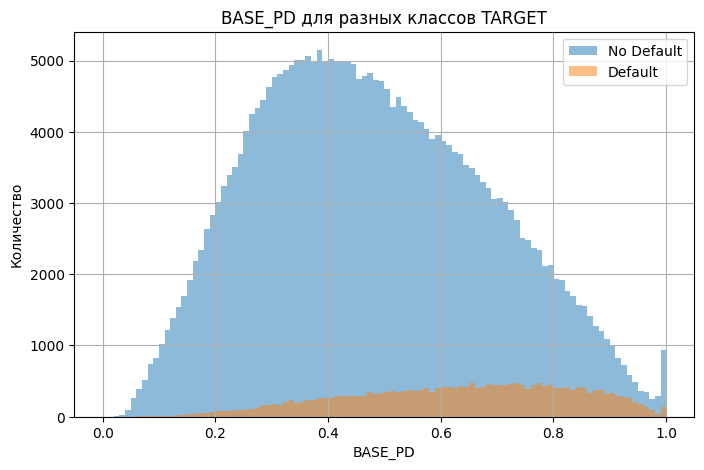

In [ ]:
plt.figure(figsize=(8, 5))

df[df["TARGET"] == 0]["BASE_PD"].hist(alpha=0.5, bins=100, label="No Default")
df[df["TARGET"] == 1]["BASE_PD"].hist(alpha=0.5, bins=100, label="Default")

plt.legend()
plt.title("BASE_PD для разных классов TARGET")
plt.xlabel("BASE_PD")
plt.ylabel("Количество")
plt.show()

In [ ]:
print(f"Средний BASE PD для клиентов, которые НЕ ВЫШЛИ в дефолт: {df[df["TARGET"] == 0]["BASE_PD"].mean().round(2)}")

Средний BASE PD для клиентов, которые НЕ ВЫШЛИ в дефолт: 0.48


In [ ]:
print(f"Средний BASE PD для клиентов, которые ВЫШЛИ в дефолт: {df[df["TARGET"] == 1]["BASE_PD"].mean().round(2)}")

Средний BASE PD для клиентов, которые ВЫШЛИ в дефолт: 0.63


Средние значения BASE PD для клиентов различных классов демонстрируют различие, однако наблюдается значительное пересечение распрдеделений. Это говорит о наличии неопределенности в оценке риска, то есть говорит о нетривиальности рассматриваемой задачи, что делает ее подходящей для применения uplift-моделирования.
То есть базовая вероятность дефолта отражает риск клиента, но при этом не обеспечивает полного разделения классов

In [ ]:
print(f"Значение метрики ROC-AUC равно: {roc_auc_score(df["TARGET"], df["BASE_PD"]).round(3)}, что говорит о наличии умеренной предсказательной способности сгенерированной переменной")

Значение метрики ROC-AUC равно: 0.703, что говорит о наличии умеренной предсказательной способности сгенерированной переменной


### Вывод: Проведенный анализ показал, что сгенерированная переменная BASE_PD:
- обладает непрерывным распределением
- демонстрирует монотонную связь с вероятностью дефолта
- позволяет разделять дефолтных и недефолтных клиентов


Это подтверждаем корректность моделирования базового кредитного риска и обоснованность использования данной переменной в дальнейших этапах построения uplift-датасета

## 2. Проверка корректности генерации Selection Bias

В данном случае мы ожидаем увидеть, что назначение коммуникации НЕ случайно

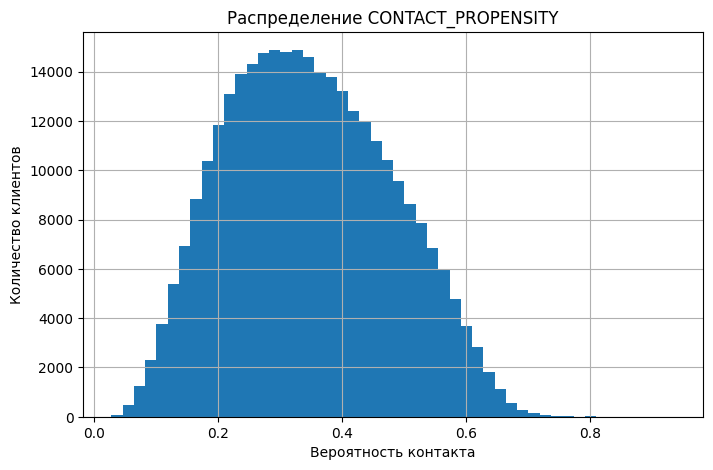

In [ ]:
plt.figure(figsize=(8, 5))
df["CONTACT_PROPENSITY"].hist(bins=50)
plt.title("Распределение CONTACT_PROPENSITY")
plt.xlabel("Вероятность контакта")
plt.ylabel("Количество клиентов")
plt.show()

Видим, что вероятность контакта варьируется между клиентами

/tmp/ipykernel_3202/1036460096.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  propensity_by_pd = df.groupby("PD_BIN")["CONTACT_PROPENSITY"].mean()


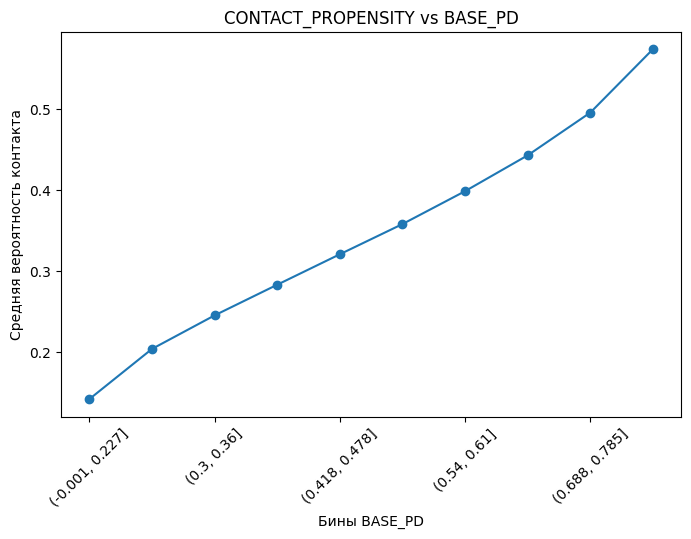

In [ ]:
df["PD_BIN"] = pd.qcut(df["BASE_PD"], q=10, duplicates="drop")

propensity_by_pd = df.groupby("PD_BIN")["CONTACT_PROPENSITY"].mean()

propensity_by_pd.plot(marker="o", figsize=(8, 5))
plt.title("CONTACT_PROPENSITY vs BASE_PD")
plt.xlabel("Бины BASE_PD")
plt.ylabel("Средняя вероятность контакта")
plt.xticks(rotation=45)
plt.show()

Видим зависимость вероятности контакта с клиентом от базового риска дефолта, что отражает реалистичную стратегию банка при которой банк чаще контактирует с более высокорисковыми клиентами.

Разделим клиентов на тех, с кем производилась и не производилась коммуникация. Ожидаем увидеть наличие значимых различий и показатель того, что коммуникации происходят с клиентами, имеющими больший риск дефолта.

In [ ]:
df["TREATED"] = df["COMMUNICATION"].apply(lambda x: "TREATED" if x != 'control' else "CONTROL")

df.groupby("TREATED")[["BASE_PD", "TARGET","AMT_CREDIT", "AMT_INCOME_TOTAL"]].mean().round(2)

,BASE_PD,TARGET,AMT_CREDIT,AMT_INCOME_TOTAL
TREATED,,,,
CONTROL,0.45,0.07,571777.31,167081.66
TREATED,0.57,0.10,650719.80,172053.86


Хотим увидеть что клиенты, получившие коммуникацию, имеют в среднем более высокий риск дефолта

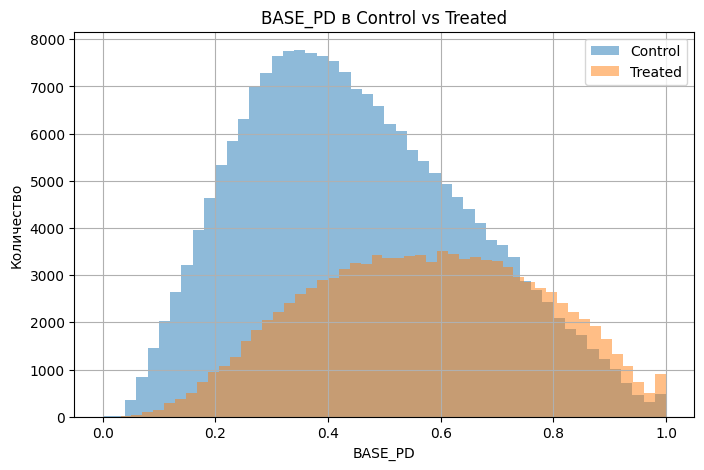

In [ ]:
plt.figure(figsize=(8, 5))

df[df["TREATED"] == "CONTROL"]["BASE_PD"].hist(alpha=0.5, bins=50, label="Control")
df[df["TREATED"] == "TREATED"]["BASE_PD"].hist(alpha=0.5, bins=50, label="Treated")

plt.legend()
plt.title("BASE_PD в Control vs Treated")
plt.xlabel("BASE_PD")
plt.ylabel("Количество")
plt.show()

## 3. Проверка корректности генерации Treatment (каналов коммуникации)

В данном случае мы так же хотим убедиться, что типы коммуникаций назначаются не случайно и соответствуют бизнес-логике.

In [ ]:
df["COMMUNICATION"].value_counts(normalize=True).round(4) * 100

,proportion
COMMUNICATION,
control,65.48
operator_call,16.49
robot_call,11.26
sms,6.77


Ожидаем увидеть распределение риска по каналам коммуникации. Более дорогие по себестоимости каналы коммуникации применяются к более высокорисковым клиентам.

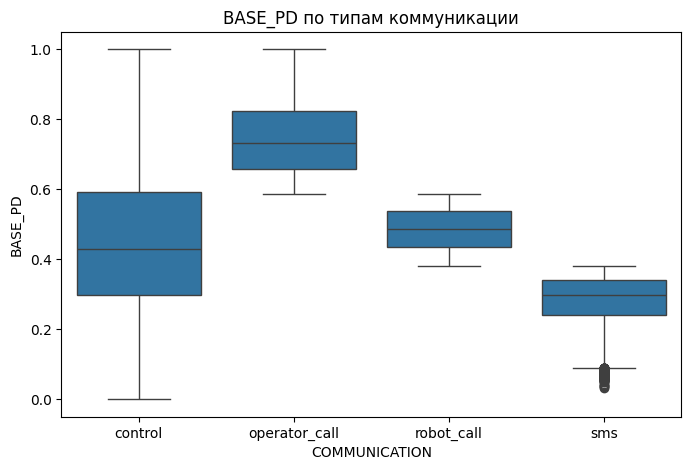

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="COMMUNICATION", y="BASE_PD")
plt.title("BASE_PD по типам коммуникации")
plt.show()

Ожидаем увидеть систематическое различие в уровне риска клиентов в зависимости от выбранного канала коммуникации.

In [ ]:
df.groupby("COMMUNICATION")["BASE_PD"].mean().round(2).sort_values()

,BASE_PD
COMMUNICATION,
sms,0.28
control,0.45
robot_call,0.49
operator_call,0.75


Видим в группе более высокий base pd. Это связано с тем, что в данную группу попадают клиенты, которым хоть и была назначена коммуникация, но она не состоялась, то есть клиенты попадют в данную группу независимо от base pd. То есть видим монотонный рост base pd у коммуникаций
- Operator_call (0.75): Самый высокий риск. Это подтверждает, что дорогостоящий ресурс оператора направляется на наиболее критических клиентов
- Robot_call (0.49): Средний уровень риска, что соответствует автоматизации работы со вторым по приоритетности эшелоном
- SMS (0.28): Минимальный риск. Канал используется для «мягкого» напоминания благонадежным клиентам
- Control (0.45): Значение находится между сегментами low и medium, так как контрольная группа формируется из представителей всех сегментов риска, оставшихся без контакта

In [ ]:
df.groupby("COMMUNICATION")["CONTACT_PROPENSITY"].mean().round(2)

,CONTACT_PROPENSITY
COMMUNICATION,
control,0.32
operator_call,0.50
robot_call,0.35
sms,0.22


Вторая таблица отражает вероятность того, что клиент будет выбран для коммуникации

- Для группы operator_call она максимальна (0.50), что логично: банк активно стремится связаться с этой группой

- Для группы sms она минимальна (0.22), так как базовая потребность в контакте с низкорисковыми клиентами ниже

- Группа control имеет среднее значение 0.32, что подтверждает наличие в контроле клиентов с разной вероятностью назначения воздействия


Вывод: Переменная CONTACT_PROPENSITY успешно создает условия для тестирования устойчивости моделей к selection bias, так как группы воздействия систематически отличаются от группы контроля по вероятности их выбора


In [ ]:
pd.crosstab(df["RISK_SEGMENT"], df["COMMUNICATION"], normalize="index").round(2)

COMMUNICATION,control,operator_call,robot_call,sms
RISK_SEGMENT,,,,
high_risk,0.51,0.49,0.00,0.0
low_risk,0.80,0.00,0.00,0.2
medium_risk,0.66,0.00,0.34,0.0


Матрица кросс-табуляции является ключевым доказательством корректности заложенной бизнес-логики

- High_risk: 50% клиентов получили звонок оператора, а 50% остались в контрольной группе
Это идеальная ситуация для оценки истинного аплифта, так как у нас есть равные группы для сравнения эффекта «со звонком» и «без него»

- Low_risk: Только 20% получили SMS, а 80% остались в контроле
Это отражает реализм: банку невыгодно тратить бюджет на тех, кто с высокой вероятностью заплатит сам

- Medium_risk: 34% получили звонок робота


Вывод: Данная таблица подтверждает реализацию Non-Random Treatment Assignment (неслучайного назначения воздействия)
. В каждом сегменте риска присутствует значительная доля контрольной группы, что критически важно для построения и оценки качества Uplift-моделей

## 4. Анализ структуры Истинного Аплифта (True Uplift)
Здесь мы проверяем, насколько разнообразно клиенты реагируют на воздействие. В Uplift-моделировании это критически важно: если эффект у всех одинаковый, модель теряет смысл

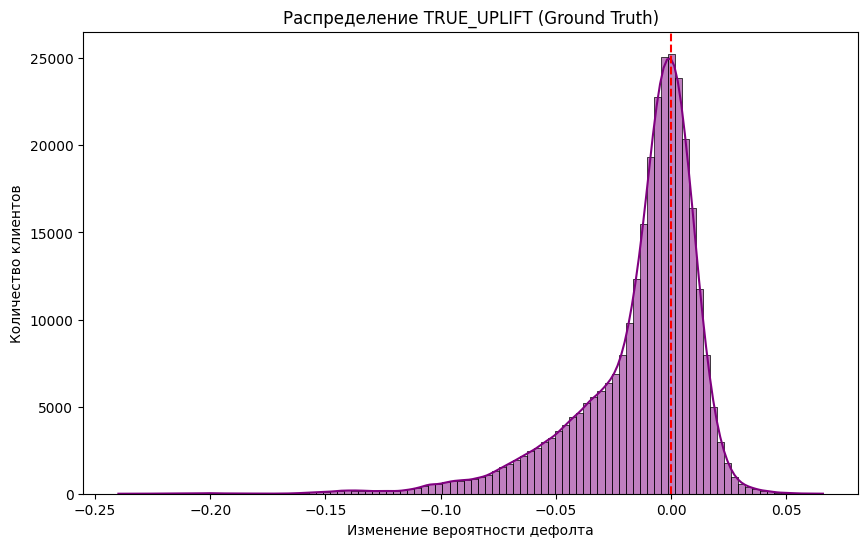

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['TRUE_UPLIFT'], bins=100, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title("Распределение TRUE_UPLIFT (Ground Truth)")
plt.xlabel("Изменение вероятности дефолта")
plt.ylabel("Количество клиентов")
plt.show()

Важный график. Нас интересуют отрицательные значения True Uplift, эти значения означают что для данных клиентов коммуникация действительно понижает вероятность дефолта. Красная линия разграничивает клиентов для которых не имеет разницы коммуницировать или нет с клиентом. А положительные значения это те клиенты, коммуникация с которыми их "раздражает" и только повышает вероятность дефолта. Вот именно такой эффект позволяют учитывать Uplift модели в отличие от классическиз подходов с определением способа коммуникаций на основе некоторого скора модели и pd.

То есь данные гетерогенны - коммуникация влияет на людей по-разному, поэтому датасет подходит для uplift-моделирования.

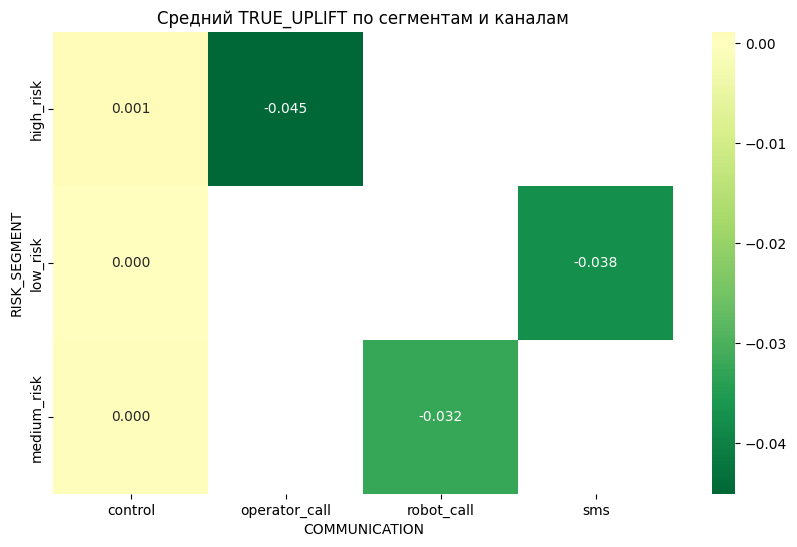

In [ ]:
# Матрица эффективности: Сегмент риска vs Канал коммуникации
uplift_pivot = df.groupby(['RISK_SEGMENT', 'COMMUNICATION'])['TRUE_UPLIFT'].mean().unstack()

plt.figure(figsize=(10, 6))
sns.heatmap(uplift_pivot, annot=True, cmap="RdYlGn_r", center=0, fmt=".3f")
plt.title("Средний TRUE_UPLIFT по сегментам и каналам")
plt.show()

На тепловой карте (Heatmap) четко видно, что воздействие работает по-разному в зависимости от сегмента и канала

- Максимальный эффект у операторов: Для группы high_risk звонок оператора дает самый сильный отрицательный аплифт (-0.045), то есть максимально снижает риск дефолта
Это подтверждает правильность выбора «сильного» канала для «тяжелых» клиентов

- Эффективность SMS для низкого риска: Для low_risk СМС-сообщения показывают уверенный эффект (-0.038), что оправдывает использование дешевого канала для профилактики в этом сегменте

- Отсутствие эффекта в контроле: В колонке control значения практически нулевые (0.000 или 0.001), что логично: если нет воздействия, то нет и изменения вероятности дефолта


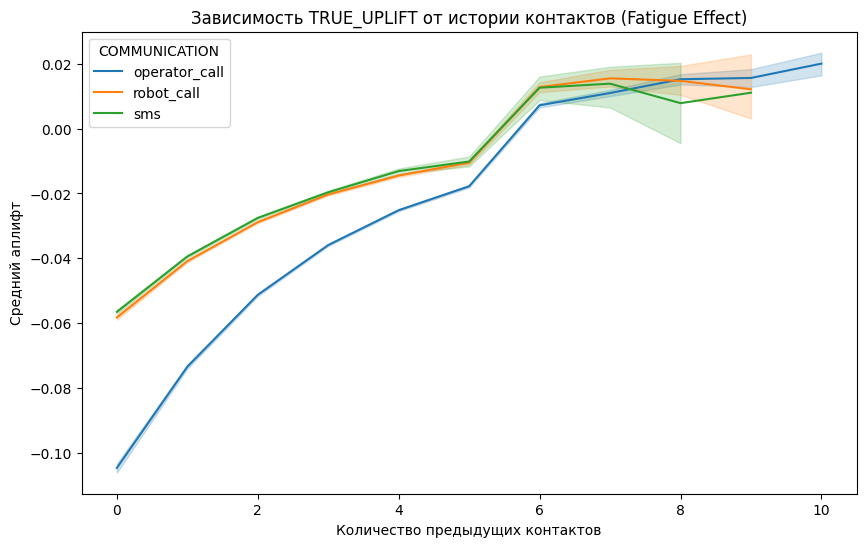

In [ ]:
# Визуализация затухания эффекта от количества контактов
plt.figure(figsize=(10, 6))
sns.lineplot(data=df[df['COMMUNICATION'] != 'control'], x='CONTACT_HISTORY', y='TRUE_UPLIFT', hue='COMMUNICATION')
plt.title("Зависимость TRUE_UPLIFT от истории контактов (Fatigue Effect)")
plt.xlabel("Количество предыдущих контактов")
plt.ylabel("Средний аплифт")
plt.show()

- Тренд к нулю: Мы видим, что при увеличении CONTACT_HISTORY (количества предыдущих контактов) линии всех каналов стремятся вверх, к нулевой отметке
Это означает, что каждый последующий звонок или СМС приносит всё меньше пользы
- Переход в «красную зону»: При достижении большого количества контактов (после 6–8) эффект для некоторых каналов становится положительным (выше нуля)
- Это визуализация того, как чрезмерное давление банка начинает вредить и повышает риск дефолта, превращая клиентов в «спящих собак»

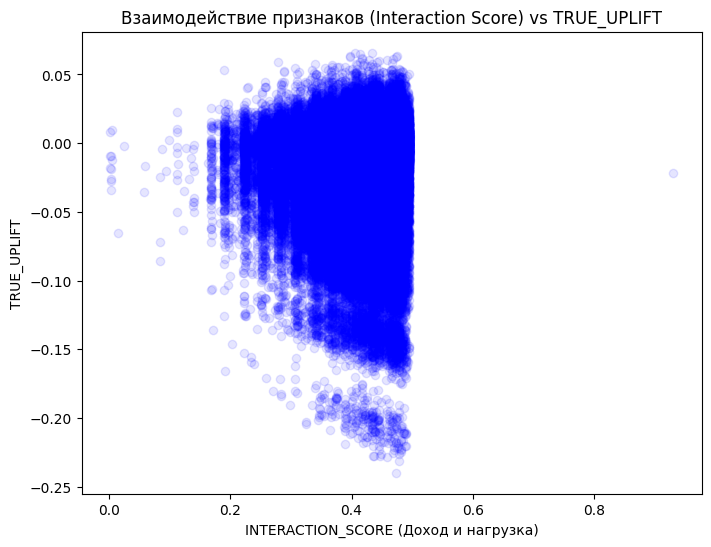

In [ ]:
# Связь Interaction Score и True Uplift
plt.figure(figsize=(8, 6))
plt.scatter(df['INTERACTION_SCORE'], df['TRUE_UPLIFT'], alpha=0.1, color='blue')
plt.title("Взаимодействие признаков (Interaction Score) vs TRUE_UPLIFT")
plt.xlabel("INTERACTION_SCORE (Доход и нагрузка)")
plt.ylabel("TRUE_UPLIFT")
plt.show()

# Что смотрим: Наличие корреляции.
# Что ожидаем увидеть: Чем выше INTERACTION_SCORE, тем сильнее должен быть выражен
# эффект (отрицательный аплифт), что создает "контекстуальную" сложность для моделей.